
### PySpark Feature Engineering + LightGBM

**Cải tiến:**
-  Xử lý TẤT CẢ file CSV (Oct 2019 → Feb 2020)
-  Feature Engineering : 35+ features
-  Phân tích trường dữ liệu trước/sau

## 0. Imports & Configuration

In [1]:
!pip install pyspark -q

import os, time, warnings
warnings.filterwarnings('ignore')
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn import metrics
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams.update({'figure.figsize':(14,6),'font.size':12,'axes.titlesize':16,'figure.dpi':100})
print('Imports OK')

Imports OK


## 1. Cấu Hình Đường Dẫn

In [2]:
KAGGLE_INPUT = '/kaggle/input/DATASETS'
COSMETICS_DIR = os.path.join(KAGGLE_INPUT, '/kaggle/input/datasets/mkechinov/ecommerce-events-history-in-cosmetics-shop')
MULTI_CAT_DIR = os.path.join(KAGGLE_INPUT, '/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store')
OUTPUT_DIR = '/kaggle/working/lgbm_output_v2'
MODEL_PATH = os.path.join(OUTPUT_DIR, 'lgbm_model_v2.txt')
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_csv_files = []
for d in [COSMETICS_DIR, MULTI_CAT_DIR]:
    if os.path.exists(d):
        for f in sorted(os.listdir(d)):
            if f.endswith('.csv'):
                all_csv_files.append(os.path.join(d, f))

print(f'{len(all_csv_files)} CSV files:')
for fp in all_csv_files:
    sz = os.path.getsize(fp)/1024**3
    print(f'  {os.path.basename(fp)} ({sz:.2f} GB)')

7 CSV files:
  2019-Dec.csv (0.39 GB)
  2019-Nov.csv (0.51 GB)
  2019-Oct.csv (0.45 GB)
  2020-Feb.csv (0.46 GB)
  2020-Jan.csv (0.47 GB)
  2019-Nov.csv (8.39 GB)
  2019-Oct.csv (5.28 GB)


## 2. Khởi Tạo Spark

In [3]:
spark = (
    SparkSession.builder
    .appName('EcommerceV2')
    .config('spark.driver.memory', '10g')
    .config('spark.executor.memory', '10g')
    .config('spark.sql.shuffle.partitions', '100')
    .config('spark.driver.maxResultSize', '4g')
    .config('spark.sql.adaptive.enabled', 'true')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f' Spark {spark.version} ready')

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/05 07:22:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


 Spark 4.0.2 ready


## 3. Load & Clean Dữ Liệu (TẤT CẢ files)

In [4]:
t0 = time.time()
df_raw = spark.read.option('header','true').option('inferSchema','true').csv(all_csv_files)
raw_count = df_raw.count()
print(f'Tong RAW: {raw_count:,} hang — {time.time()-t0:.1f}s')
df_raw.printSchema()

Tong RAW: 130,643,583 hang — 228.5s
root
 |-- event_time: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- category_id: long (nullable = true)
 |-- category_code: string (nullable = true)
 |-- brand: string (nullable = true)
 |-- price: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- user_session: string (nullable = true)



### 3.1  Phân Tích Trường Dữ Liệu GỐC (Trước FE)

In [8]:
print('=' * 70)
print('   PHÂN TÍCH TRƯỜNG DỮ LIỆU GỐC')
print('=' * 70)
col_info = []
for c in df_raw.columns:
    dtype = str(df_raw.schema[c].dataType)
    null_count = df_raw.filter(F.col(c).isNull()).count()
    null_pct = null_count / raw_count * 100
    n_dist = df_raw.select(c).distinct().count()
    col_info.append({'Cột': c, 'Kiểu': dtype, 'Null': f'{null_count:,}', '%Null': f'{null_pct:.2f}%', 'Unique': f'{n_dist:,}'})
field_df = pd.DataFrame(col_info)
print(field_df.to_string(index=False))
df_raw.show(5, truncate=False)

   PHÂN TÍCH TRƯỜNG DỮ LIỆU GỐC


          Cột            Kiểu       Null  %Null     Unique
   event_time TimestampType()          0  0.00% 10,395,630
   event_type    StringType()          0  0.00%          4
   product_id   IntegerType()          0  0.00%    261,093
  category_id      LongType()          0  0.00%      1,216
category_code    StringType() 55,753,026 42.68%        132
        brand    StringType() 24,088,360 18.44%      4,515
        price    DoubleType()          0  0.00%     83,023
      user_id   IntegerType()          0  0.00%  6,955,212
 user_session    StringType()      4,610  0.00% 27,552,588
+-------------------+----------------+----------+-------------------+-------------+---------+-----+---------+------------------------------------+
|event_time         |event_type      |product_id|category_id        |category_code|brand    |price|user_id  |user_session                        |
+-------------------+----------------+----------+-------------------+-------------+---------+-----+---------+-------

### 3.2 Làm Sạch & Parse Datetime

In [ ]:
df = (
    df_raw
    .filter(F.col('user_session').isNotNull() & F.col('user_id').isNotNull() & F.col('product_id').isNotNull() & F.col('price').isNotNull() & (F.col('price') > 0))
    .fillna('unknown', subset=['brand', 'category_code'])
    .withColumn('event_ts', F.to_timestamp(F.substring(F.col('event_time'),1,19),'yyyy-MM-dd HH:mm:ss'))
    .withColumn('event_date', F.to_date(F.col('event_ts')))
    .withColumn('event_hour', F.hour(F.col('event_ts')).cast(IntegerType()))
    .withColumn('event_weekday', F.dayofweek(F.col('event_date')).cast(IntegerType()))
    .withColumn('event_month', F.month(F.col('event_date')).cast(IntegerType()))
    .withColumn('is_weekend', F.when(F.dayofweek(F.col('event_date')).isin([1,7]),1).otherwise(0))
    .withColumn('is_purchased', F.when(F.col('event_type')=='purchase',1).otherwise(0))
    
    .withColumn('_cat_parts', F.split(F.col('category_code'), '\\.'))
    .withColumn('category_level1',
        F.when(F.col('category_code') != 'unknown',
               F.col('_cat_parts').getItem(0)).otherwise('unknown'))
    .withColumn('category_level2',
        F.when((F.col('category_code') != 'unknown') & (F.size(F.col('_cat_parts')) > 1),
               F.col('_cat_parts').getItem(1)).otherwise('unknown'))
    .drop('_cat_parts')
    .withColumn('price_log', F.log1p(F.col('price')))
)
clean_count = df.count()
print(f'Sau lam sach: {clean_count:,} (loai {raw_count-clean_count:,})')


## 4.  EDA 
### 4.1 Phân Bố Event Type

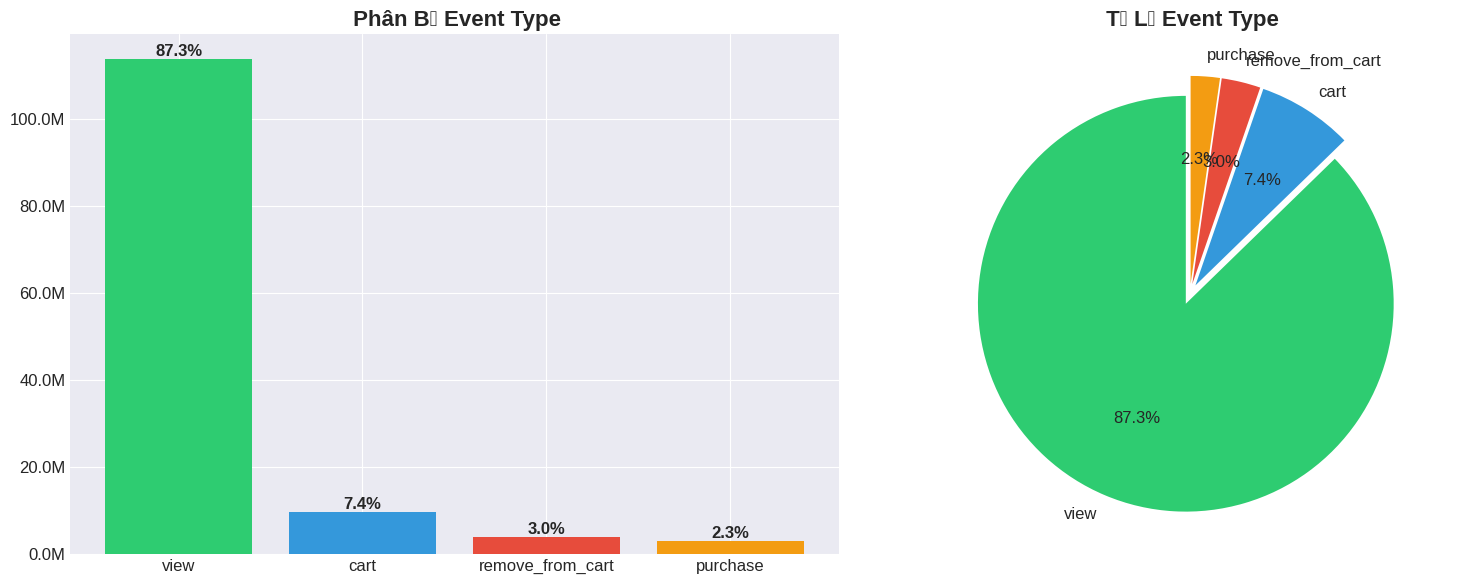

      event_type     count       pct
            view 113710604 87.283094
            cart   9666064  7.419572
remove_from_cart   3954589  3.035502
        purchase   2946668  2.261832


In [11]:
event_dist = df.groupBy('event_type').agg(F.count('*').alias('count')).orderBy(F.desc('count')).toPandas()
event_dist['pct'] = event_dist['count'] / event_dist['count'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
bars = axes[0].bar(event_dist['event_type'], event_dist['count'], color=colors[:len(event_dist)])
axes[0].set_title(' Phân Bố Event Type', fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for bar, pct in zip(bars, event_dist['pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height(), f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].pie(event_dist['count'], labels=event_dist['event_type'], autopct='%1.1f%%', colors=colors[:len(event_dist)], startangle=90, explode=[0.05]*len(event_dist))
axes[1].set_title(' Tỉ Lệ Event Type', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'event_distribution.png'), dpi=150, bbox_inches='tight'); plt.show()
print(event_dist.to_string(index=False))

### 4.2 Xu Hướng Hàng Ngày

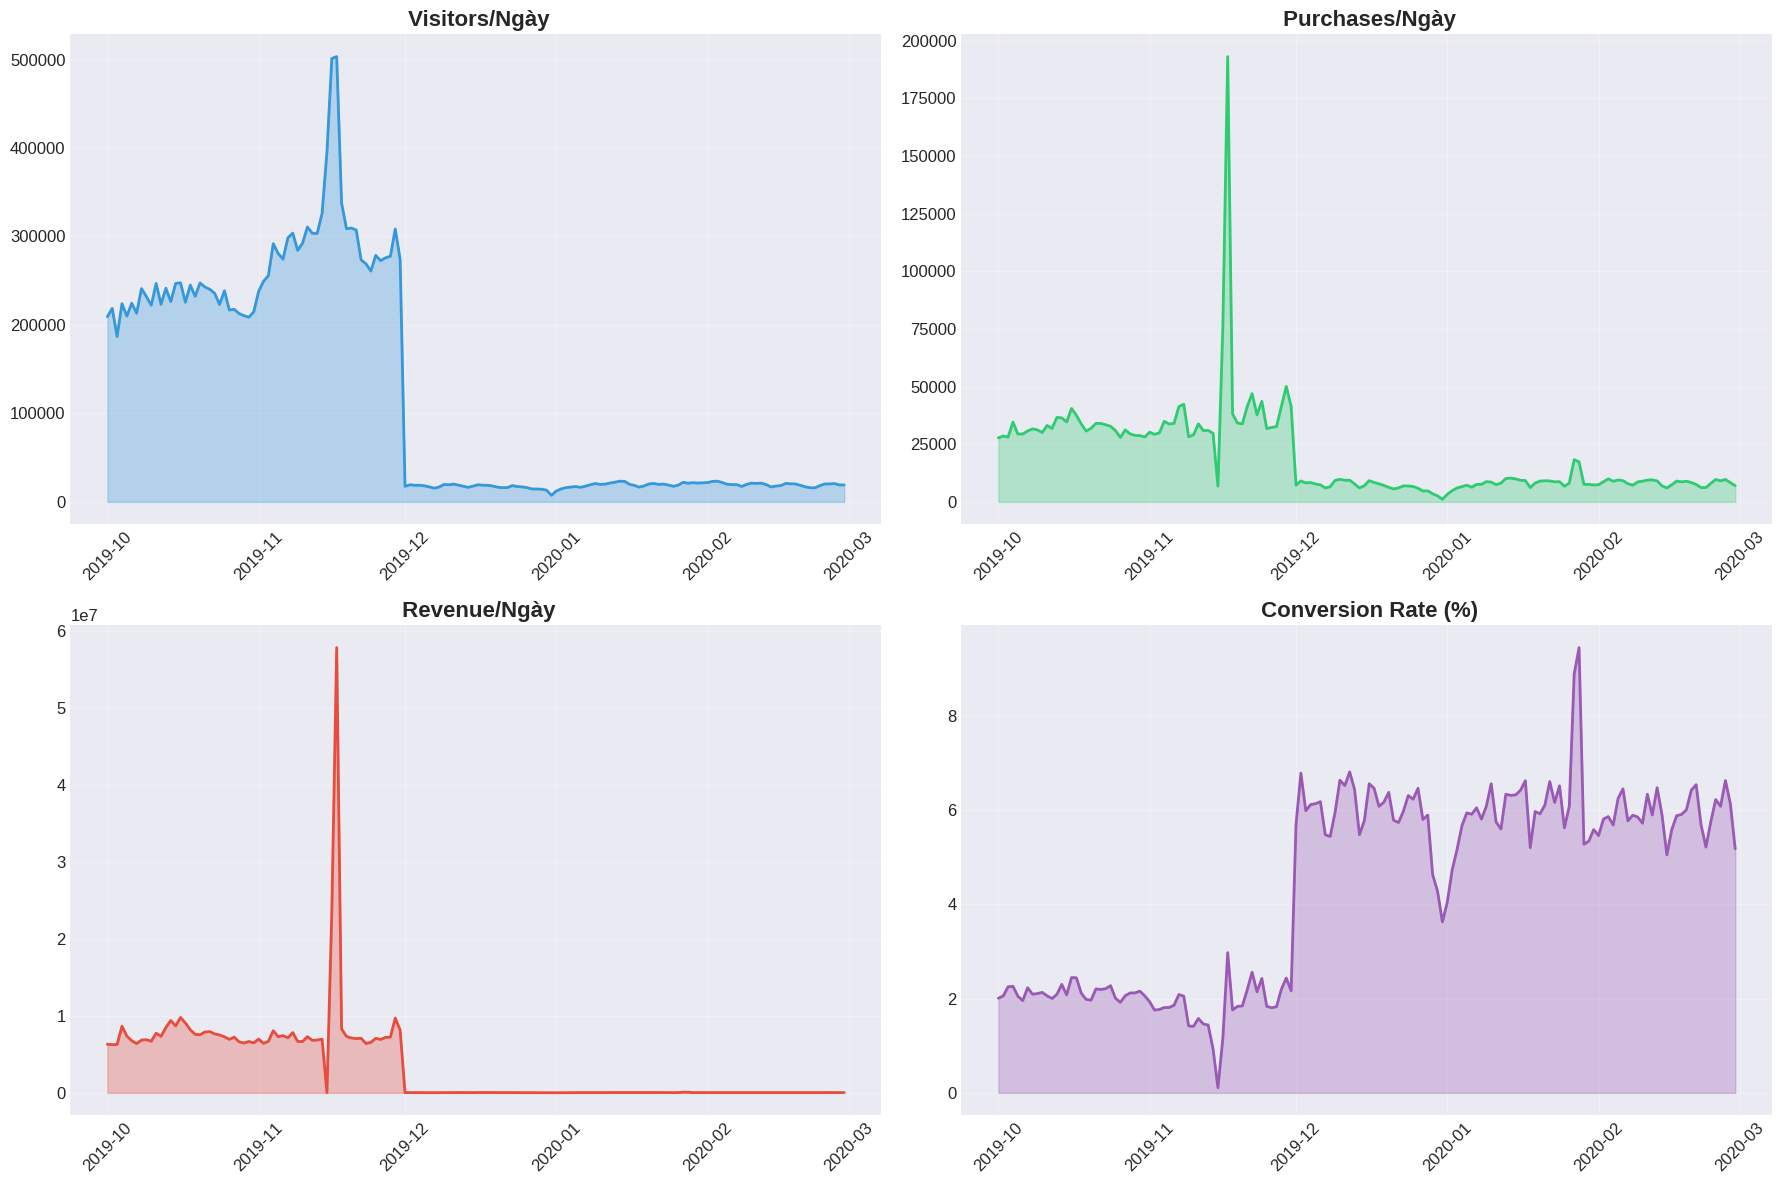

In [12]:
daily = df.groupBy('event_date').agg(
    F.countDistinct('user_id').alias('visitors'),
    F.sum('is_purchased').alias('purchases'),
    F.count('*').alias('events'),
    F.sum(F.when(F.col('event_type')=='purchase', F.col('price')).otherwise(0)).alias('revenue'),
).orderBy('event_date').toPandas()
daily['conv_rate'] = daily['purchases'] / daily['events'] * 100

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, col, title, color in zip(axes.flat,
    ['visitors', 'purchases', 'revenue', 'conv_rate'],
    [' Visitors/Ngày', ' Purchases/Ngày', ' Revenue/Ngày', ' Conversion Rate (%)'],
    ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']):
    ax.fill_between(daily['event_date'], daily[col], alpha=0.3, color=color)
    ax.plot(daily['event_date'], daily[col], color=color, linewidth=2)
    ax.set_title(title, fontweight='bold'); ax.grid(True, alpha=0.3); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'daily_trends.png'), dpi=150, bbox_inches='tight'); plt.show()

### 4.3 Phân Tích Theo Giờ

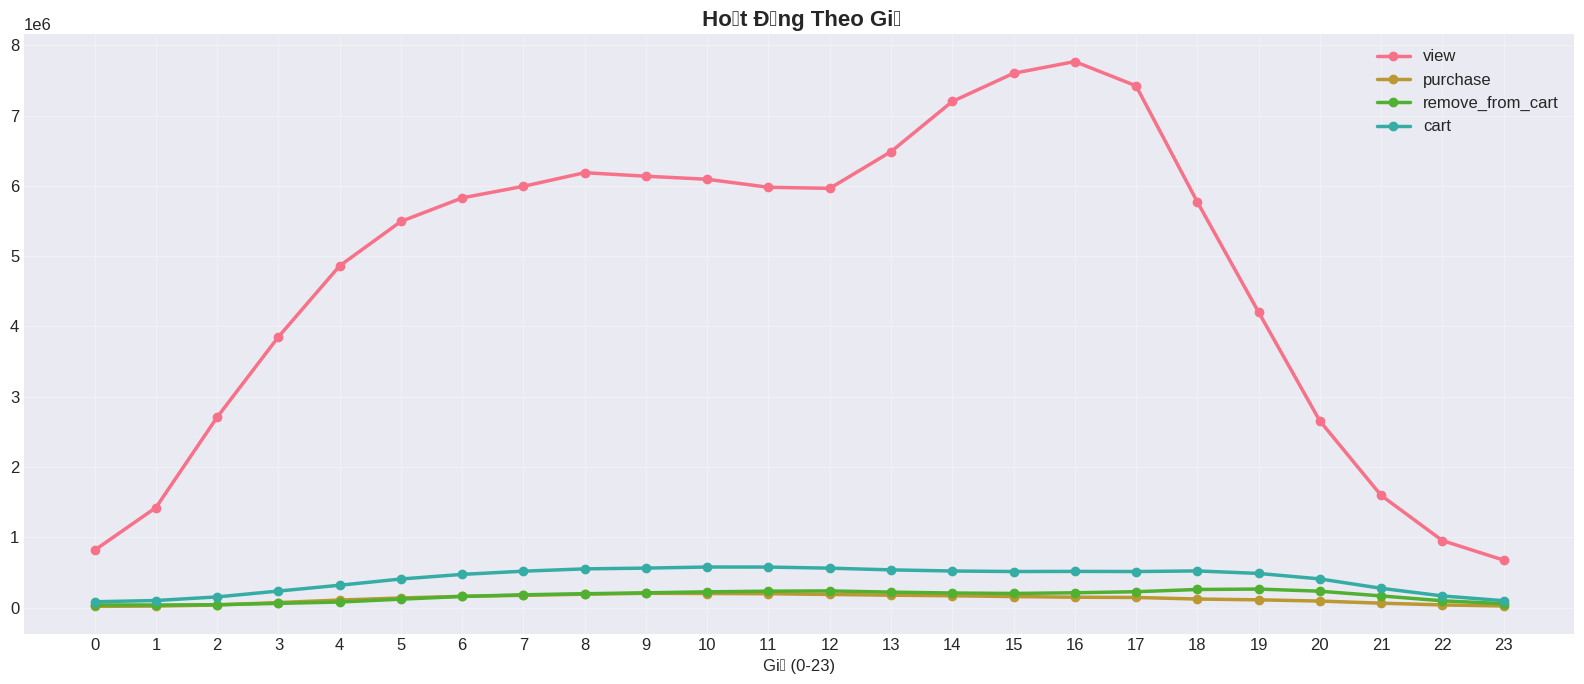

In [13]:
hourly = df.groupBy('event_hour', 'event_type').agg(F.count('*').alias('count')).orderBy('event_hour').toPandas()
fig, ax = plt.subplots(figsize=(16, 7))
for etype in hourly['event_type'].unique():
    sub = hourly[hourly['event_type']==etype]
    ax.plot(sub['event_hour'], sub['count'], marker='o', linewidth=2.5, label=etype)
ax.set_title(' Hoạt Động Theo Giờ', fontweight='bold'); ax.set_xlabel('Giờ (0-23)'); ax.set_xticks(range(24))
ax.legend(fontsize=12); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'hourly_pattern.png'), dpi=150, bbox_inches='tight'); plt.show()

### 4.4 Phân Bố Giá

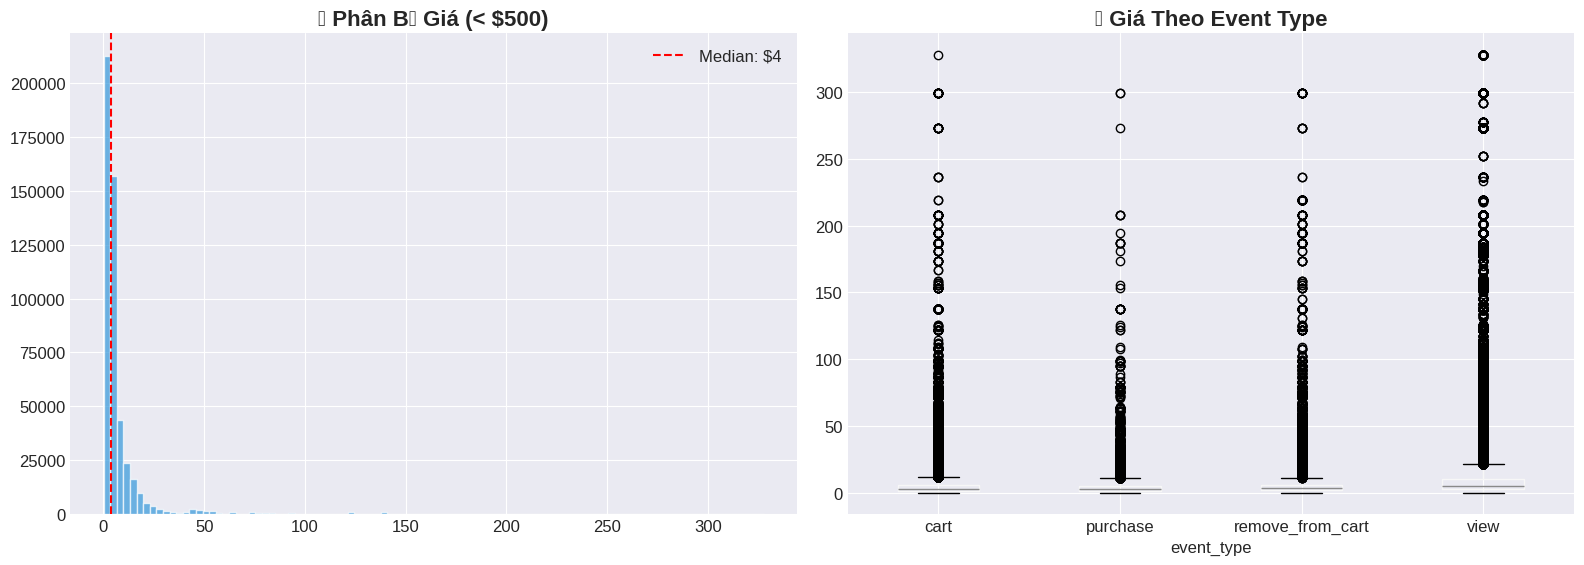

                     count   mean    std   min   25%   50%    75%     max
event_type                                                               
cart              137087.0   5.07  10.01  0.05  1.51  3.00   5.54  327.78
purchase           30871.0   4.71   8.19  0.05  1.43  2.86   5.24  299.81
remove_from_cart   96578.0   5.30  10.79  0.05  1.73  3.33   5.56  299.81
view              235464.0  12.91  27.02  0.05  2.70  5.13  10.32  327.78


In [14]:
price_pd = df.select('price','event_type').filter(F.col('price')<500).limit(500000).toPandas()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].hist(price_pd['price'], bins=100, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(price_pd['price'].median(), color='red', linestyle='--', label=f'Median: ${price_pd["price"].median():.0f}')
axes[0].set_title('📊 Phân Bố Giá (< $500)', fontweight='bold'); axes[0].legend()
price_pd.boxplot(column='price', by='event_type', ax=axes[1])
axes[1].set_title('📦 Giá Theo Event Type', fontweight='bold'); plt.suptitle('')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'price_dist.png'), dpi=150, bbox_inches='tight'); plt.show()
print(price_pd.groupby('event_type')['price'].describe().round(2))

### 4.5 Top 20 Brands Theo Revenue

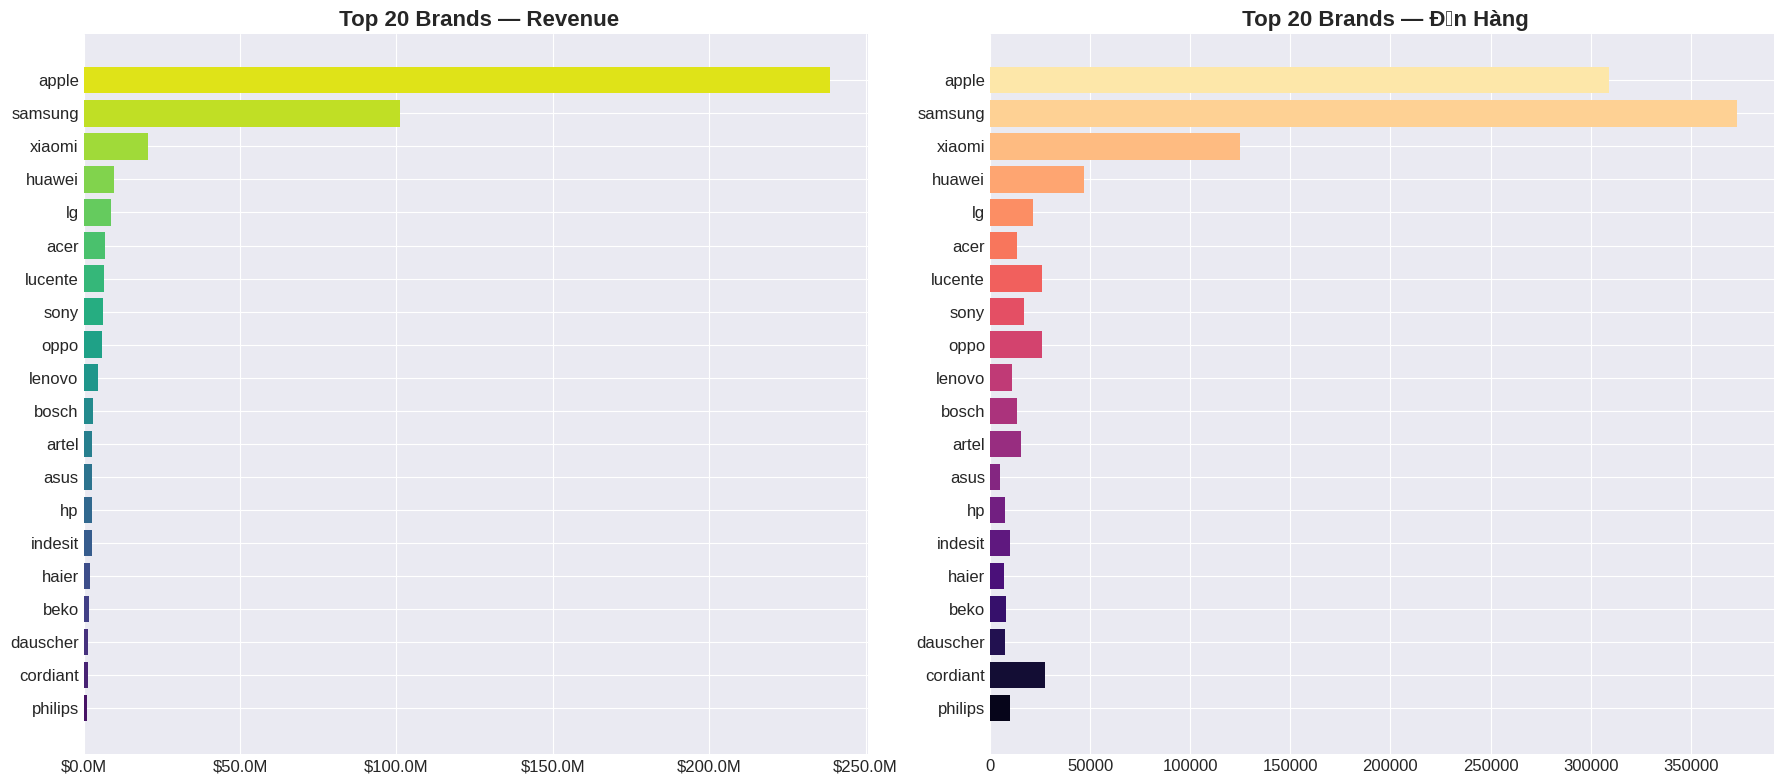

In [15]:
brand_rev = df.filter((F.col('event_type')=='purchase') & (F.col('brand')!='unknown')).groupBy('brand').agg(
    F.sum('price').alias('revenue'), F.count('*').alias('purchases'), F.mean('price').alias('avg_price')
).orderBy(F.desc('revenue')).limit(20).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].barh(brand_rev['brand'][::-1], brand_rev['revenue'][::-1], color=sns.color_palette('viridis', 20))
axes[0].set_title(' Top 20 Brands — Revenue', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[1].barh(brand_rev['brand'][::-1], brand_rev['purchases'][::-1], color=sns.color_palette('magma', 20))
axes[1].set_title(' Top 20 Brands — Đơn Hàng', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'top_brands.png'), dpi=150, bbox_inches='tight'); plt.show()

### 4.6 Phân Tích Categories

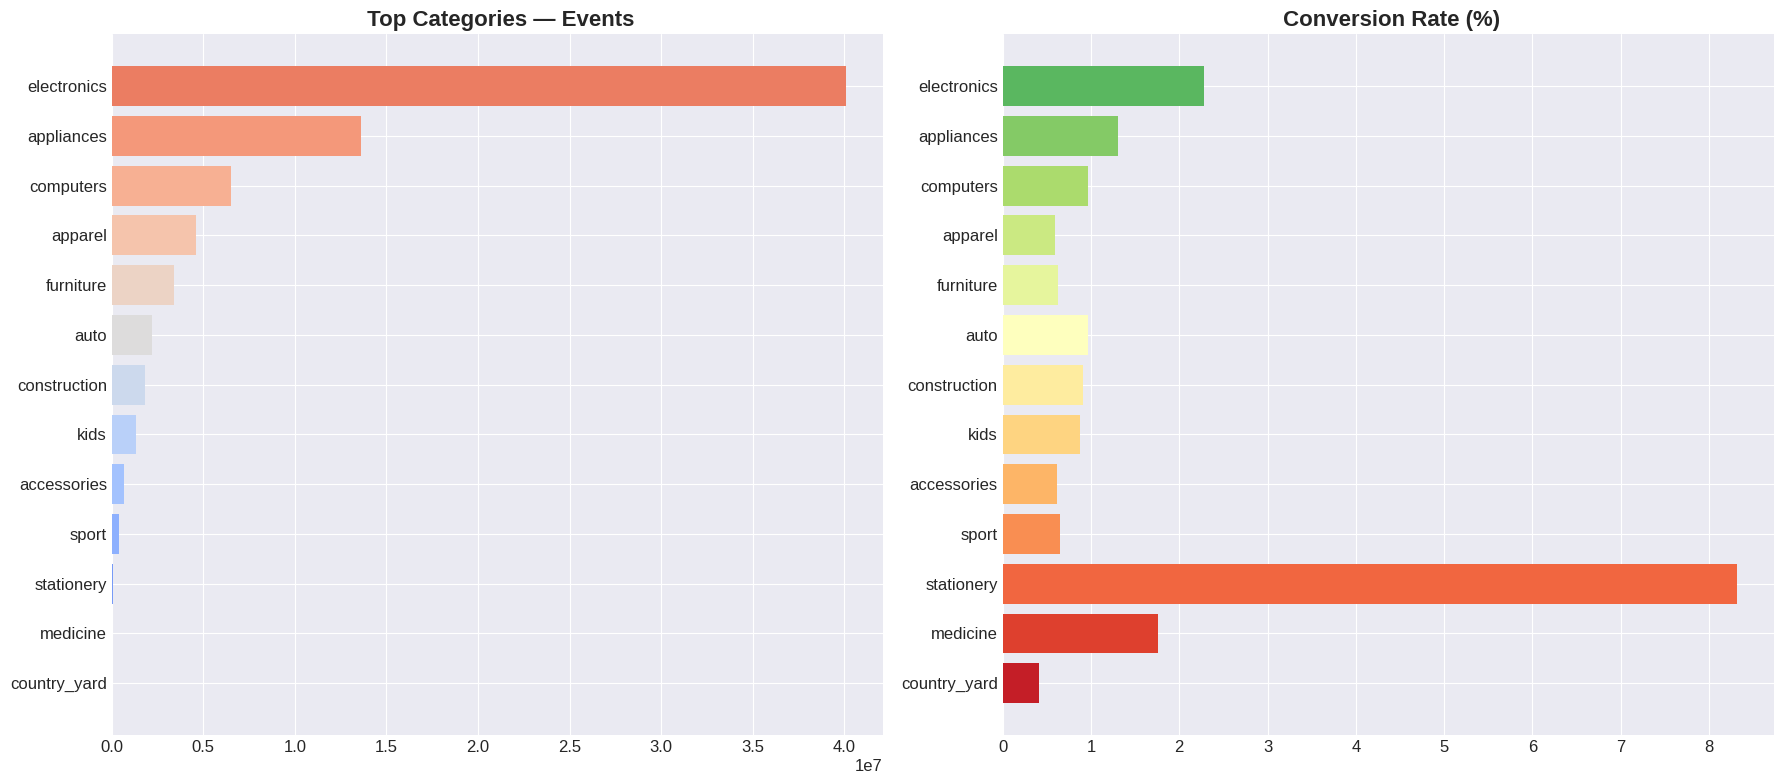

In [16]:
cat_stats = df.filter(F.col('category_level1')!='unknown').groupBy('category_level1').agg(
    F.count('*').alias('events'), F.sum('is_purchased').alias('purchases'),
    F.sum(F.when(F.col('event_type')=='purchase', F.col('price')).otherwise(0)).alias('revenue'),
).withColumn('conv_rate', F.col('purchases')/F.col('events')*100).orderBy(F.desc('events')).limit(15).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].barh(cat_stats['category_level1'][::-1], cat_stats['events'][::-1], color=sns.color_palette('coolwarm', 15))
axes[0].set_title(' Top Categories — Events', fontweight='bold')
axes[1].barh(cat_stats['category_level1'][::-1], cat_stats['conv_rate'][::-1], color=sns.color_palette('RdYlGn', 15))
axes[1].set_title(' Conversion Rate (%)', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'category_analysis.png'), dpi=150, bbox_inches='tight'); plt.show()

### 4.7 Phân Tích Theo Ngày Trong Tuần

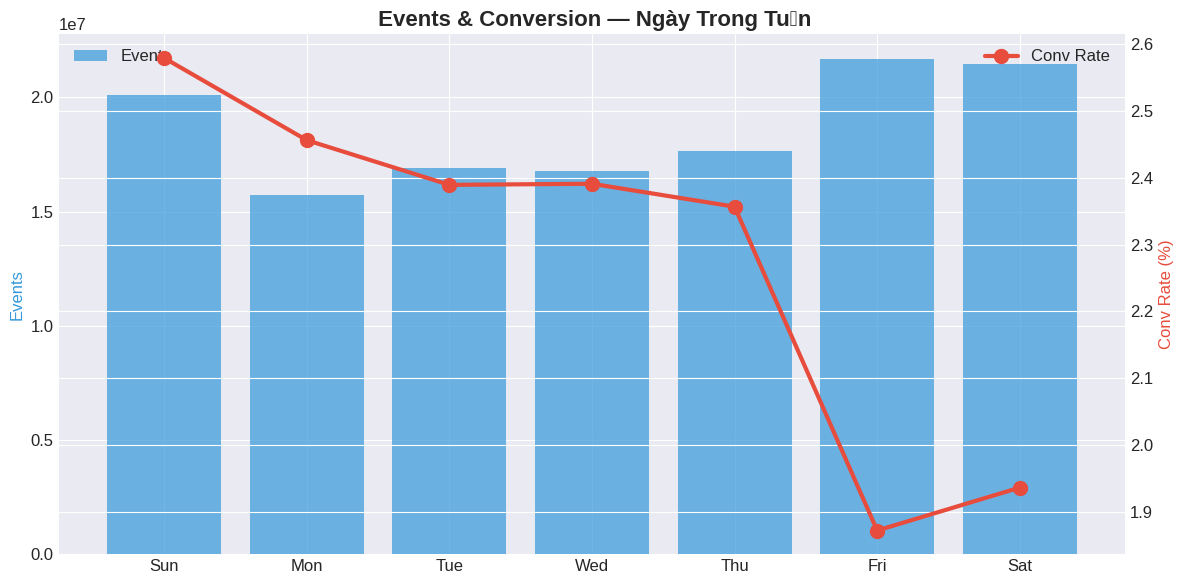

In [17]:
wd = df.groupBy('event_weekday').agg(F.count('*').alias('events'), F.sum('is_purchased').alias('purchases')
).withColumn('conv_rate', F.col('purchases')/F.col('events')*100).orderBy('event_weekday').toPandas()
wd['day'] = wd['event_weekday'].map({1:'Sun',2:'Mon',3:'Tue',4:'Wed',5:'Thu',6:'Fri',7:'Sat'})

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
ax1.bar(wd['day'], wd['events'], color='#3498db', alpha=0.7, label='Events')
ax2.plot(wd['day'], wd['conv_rate'], color='#e74c3c', marker='o', linewidth=3, markersize=10, label='Conv Rate')
ax1.set_title(' Events & Conversion — Ngày Trong Tuần', fontweight='bold')
ax1.set_ylabel('Events', color='#3498db'); ax2.set_ylabel('Conv Rate (%)', color='#e74c3c')
ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'weekday.png'), dpi=150, bbox_inches='tight'); plt.show()

### 4.8 Purchase Funnel

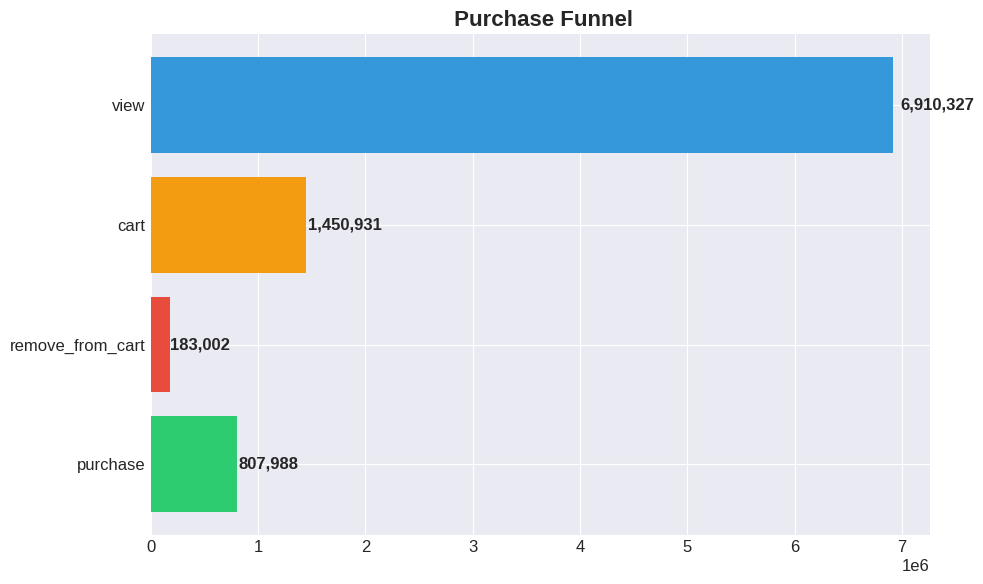

In [19]:
funnel = df.groupBy('event_type').agg(F.countDistinct('user_id').alias('users')).toPandas()
order = ['view','cart','remove_from_cart','purchase']
funnel = funnel.set_index('event_type').reindex([o for o in order if o in funnel['event_type'].values]).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3498db','#f39c12','#e74c3c','#2ecc71']
bars = ax.barh(funnel['event_type'][::-1], funnel['users'][::-1], color=colors[:len(funnel)][::-1])
for bar, val in zip(bars, funnel['users'][::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2, f'{val:,}', va='center', fontweight='bold')
ax.set_title(' Purchase Funnel', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'funnel.png'), dpi=150, bbox_inches='tight'); plt.show()

### 4.9 Monthly Trend

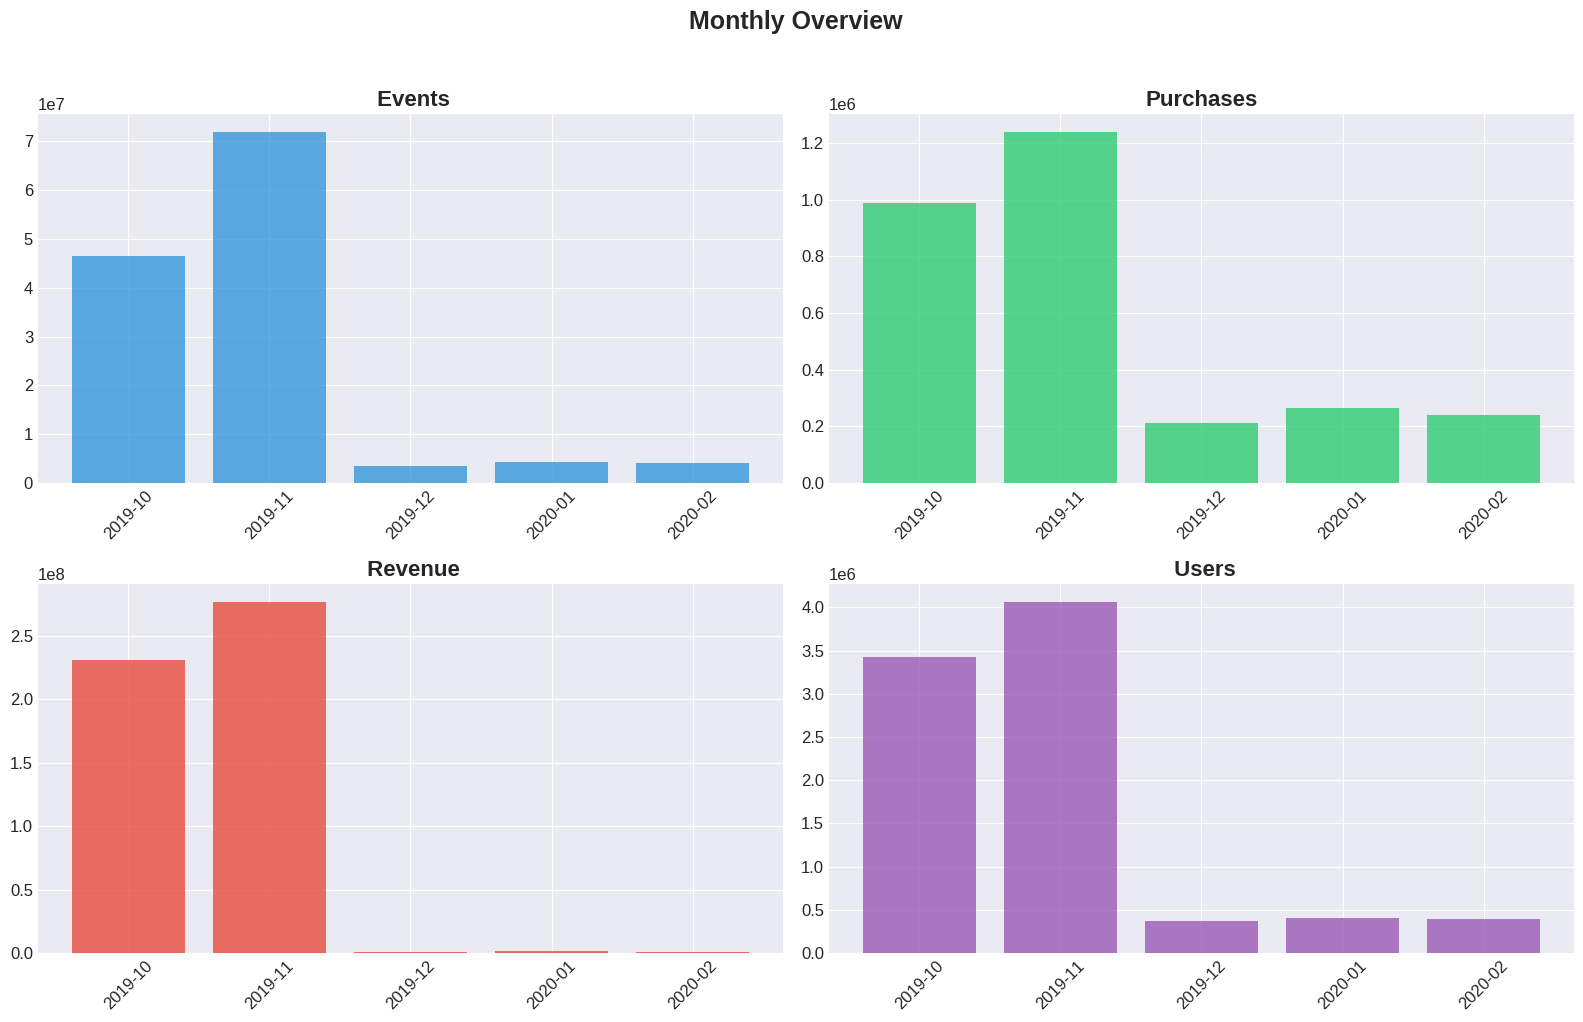

In [20]:
monthly = df.withColumn('ym', F.date_format('event_date','yyyy-MM')).groupBy('ym').agg(
    F.count('*').alias('events'), F.sum('is_purchased').alias('purchases'),
    F.sum(F.when(F.col('event_type')=='purchase', F.col('price')).otherwise(0)).alias('revenue'),
    F.countDistinct('user_id').alias('users')
).orderBy('ym').toPandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col, title, c in zip(axes.flat, ['events','purchases','revenue','users'],
    [' Events','Purchases',' Revenue',' Users'], ['#3498db','#2ecc71','#e74c3c','#9b59b6']):
    ax.bar(monthly['ym'], monthly[col], color=c, alpha=0.8)
    ax.set_title(title, fontweight='bold'); ax.tick_params(axis='x', rotation=45)
plt.suptitle(' Monthly Overview', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'monthly.png'), dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
from pyspark.sql import Window

def prior_window(*cols):
    return Window.partitionBy(*cols).orderBy('event_ts').rowsBetween(Window.unboundedPreceding, -1)

def first_flag(*cols):
    return F.when(
        F.row_number().over(Window.partitionBy(*cols).orderBy('event_ts')) == 1,
        F.lit(1)
    ).otherwise(F.lit(0))

def safe_div(numer, denom):
    return F.when((denom.isNotNull()) & (denom > 0), numer / denom).otherwise(F.lit(0.0))

## 5.  Feature Engineering Nâng Cao (35+ Features)
### 5.1 User-Level Features

In [7]:
w_user = prior_window('user_id')

user_tmp = (
    df
    .withColumn('user_view_flag', F.when(F.col('event_type') == 'view', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('user_cart_flag', F.when(F.col('event_type') == 'cart', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('user_purchase_flag', F.when(F.col('event_type') == 'purchase', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('user_purchase_price_flag', F.when(F.col('event_type') == 'purchase', F.col('price')).otherwise(F.lit(None)))
    .withColumn('user_first_session_flag', first_flag('user_id', 'user_session'))
    .withColumn('user_first_day_flag', first_flag('user_id', 'event_date'))
    .withColumn('user_first_product_flag', first_flag('user_id', 'product_id'))
    .withColumn('user_first_brand_flag', first_flag('user_id', 'brand'))
    .withColumn('user_first_category_flag', first_flag('user_id', 'category_level1'))
)

user_feats = (
    user_tmp
    .withColumn('user_total_sessions', F.coalesce(F.sum('user_first_session_flag').over(w_user), F.lit(0)))
    .withColumn('user_active_days', F.coalesce(F.sum('user_first_day_flag').over(w_user), F.lit(0)))
    .withColumn('user_total_views', F.coalesce(F.sum('user_view_flag').over(w_user), F.lit(0)))
    .withColumn('user_total_carts', F.coalesce(F.sum('user_cart_flag').over(w_user), F.lit(0)))
    .withColumn('user_total_purchases', F.coalesce(F.sum('user_purchase_flag').over(w_user), F.lit(0)))
    .withColumn('user_total_events_tmp', F.coalesce(F.count(F.lit(1)).over(w_user), F.lit(0)))
    .withColumn('user_avg_price', F.coalesce(F.avg('price').over(w_user), F.lit(0.0)))
    .withColumn('user_price_std', F.coalesce(F.stddev('price').over(w_user), F.lit(0.0)))
    .withColumn('user_avg_purchase_price', F.coalesce(F.avg('user_purchase_price_flag').over(w_user), F.lit(0.0)))
    .withColumn('user_unique_products', F.coalesce(F.sum('user_first_product_flag').over(w_user), F.lit(0)))
    .withColumn('user_unique_brands', F.coalesce(F.sum('user_first_brand_flag').over(w_user), F.lit(0)))
    .withColumn('user_unique_categories', F.coalesce(F.sum('user_first_category_flag').over(w_user), F.lit(0)))
    .withColumn('user_purchase_rate', safe_div(F.col('user_total_purchases'), F.col('user_total_events_tmp')))
    .withColumn('user_cart_rate', safe_div(F.col('user_total_carts'), F.col('user_total_events_tmp')))
    .withColumn('user_cart_to_purchase', safe_div(F.col('user_total_carts'), F.col('user_total_purchases')))
    .select(
        'user_id',
        'user_total_sessions', 'user_active_days', 'user_total_views', 'user_total_carts', 'user_total_purchases',
        'user_purchase_rate', 'user_cart_rate', 'user_cart_to_purchase', 'user_avg_price', 'user_price_std',
        'user_avg_purchase_price', 'user_unique_products', 'user_unique_brands', 'user_unique_categories'
    )
    .fillna(0)
)

print(f' User features (leakage-safe): {len(user_feats.columns) - 1}')

 User features: 16


### 5.2 Product-Level Features

In [8]:
w_product = prior_window('product_id')

product_tmp = (
    df
    .withColumn('product_view_flag', F.when(F.col('event_type') == 'view', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('product_cart_flag', F.when(F.col('event_type') == 'cart', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('product_purchase_flag', F.when(F.col('event_type') == 'purchase', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('product_first_viewer_flag', first_flag('product_id', 'user_id'))
)

product_feats = (
    product_tmp
    .withColumn('product_unique_viewers', F.coalesce(F.sum('product_first_viewer_flag').over(w_product), F.lit(0)))
    .withColumn('product_total_views', F.coalesce(F.sum('product_view_flag').over(w_product), F.lit(0)))
    .withColumn('product_total_carts', F.coalesce(F.sum('product_cart_flag').over(w_product), F.lit(0)))
    .withColumn('product_total_purchases', F.coalesce(F.sum('product_purchase_flag').over(w_product), F.lit(0)))
    .withColumn('product_total_events_tmp', F.coalesce(F.count(F.lit(1)).over(w_product), F.lit(0)))
    .withColumn('product_avg_price', F.coalesce(F.avg('price').over(w_product), F.lit(0.0)))
    .withColumn('product_price_std', F.coalesce(F.stddev('price').over(w_product), F.lit(0.0)))
    .withColumn('product_min_price', F.coalesce(F.min('price').over(w_product), F.lit(0.0)))
    .withColumn('product_max_price', F.coalesce(F.max('price').over(w_product), F.lit(0.0)))
    .withColumn('product_cart2purchase', safe_div(F.col('product_total_purchases'), F.col('product_total_carts')))
    .withColumn('product_view2cart', safe_div(F.col('product_total_carts'), F.col('product_total_views')))
    .withColumn('product_popularity', safe_div(F.col('product_unique_viewers'), F.col('product_total_events_tmp')))
    .select(
        'product_id',
        'product_unique_viewers', 'product_total_purchases', 'product_total_carts',
        'product_cart2purchase', 'product_view2cart', 'product_avg_price', 'product_price_std',
        'product_popularity'
    )
    .fillna(0)
)

print(f' Product features (leakage-safe): {len(product_feats.columns) - 1}')

 Product features: 12


### 5.3 Session-Level Features

In [9]:
w_session = prior_window('user_session')

session_tmp = (
    df
    .withColumn('session_view_flag', F.when(F.col('event_type') == 'view', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('session_cart_flag', F.when(F.col('event_type') == 'cart', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('session_first_product_flag', first_flag('user_session', 'product_id'))
    .withColumn('session_first_brand_flag', first_flag('user_session', 'brand'))
)

session_feats = (
    session_tmp
    .withColumn('session_total_events', F.coalesce(F.count(F.lit(1)).over(w_session), F.lit(0)))
    .withColumn('session_view_count', F.coalesce(F.sum('session_view_flag').over(w_session), F.lit(0)))
    .withColumn('session_cart_count', F.coalesce(F.sum('session_cart_flag').over(w_session), F.lit(0)))
    .withColumn('session_unique_products', F.coalesce(F.sum('session_first_product_flag').over(w_session), F.lit(0)))
    .withColumn('session_unique_brands', F.coalesce(F.sum('session_first_brand_flag').over(w_session), F.lit(0)))
    .withColumn('session_avg_price', F.coalesce(F.avg('price').over(w_session), F.lit(0.0)))
    .withColumn('session_max_price', F.coalesce(F.max('price').over(w_session), F.lit(0.0)))
    .withColumn('session_min_price', F.coalesce(F.min('price').over(w_session), F.lit(0.0)))
    .withColumn('session_price_range', F.col('session_max_price') - F.col('session_min_price'))
    .select(
        'user_session',
        'session_total_events', 'session_view_count', 'session_cart_count',
        'session_unique_products', 'session_unique_brands',
        'session_avg_price', 'session_price_range'
    )
    .fillna(0)
)

print(f' Session features (leakage-safe): {len(session_feats.columns) - 1}')

 Session features: 8


### 5.4 User × Product Interaction

In [10]:
w_up = prior_window('user_id', 'product_id')

up_tmp = (
    df
    .withColumn('up_view_flag', F.when(F.col('event_type') == 'view', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('up_cart_flag', F.when(F.col('event_type') == 'cart', F.lit(1)).otherwise(F.lit(0)))
    .withColumn('up_first_session_flag', first_flag('user_id', 'product_id', 'user_session'))
)

user_product_feats = (
    up_tmp
    .withColumn('up_view_count', F.coalesce(F.sum('up_view_flag').over(w_up), F.lit(0)))
    .withColumn('up_cart_count', F.coalesce(F.sum('up_cart_flag').over(w_up), F.lit(0)))
    .withColumn('up_sessions', F.coalesce(F.sum('up_first_session_flag').over(w_up), F.lit(0)))
    .select('user_id', 'product_id', 'up_view_count', 'up_cart_count', 'up_sessions')
    .fillna(0)
)

print(f' User×Product features (leakage-safe): {len(user_product_feats.columns) - 2}')

 User×Product features: 4


## 6. Join & Tạo Dataset

In [11]:
# Sample một phần dữ liệu để giảm kích thước, nhưng giữ cả positive và negative
df_sample = df.sample(fraction=0.6, seed=42)
print(f'df_sample: {df_sample.count():,}')

# Giải phóng df gốc
df.unpersist()

df_rich = (
    df_sample
    .join(user_feats, on='user_id', how='left')
    .join(product_feats, on='product_id', how='left')
    .join(session_feats, on='user_session', how='left')
    .join(user_product_feats, on=['user_id', 'product_id'], how='left')
    .withColumn(
        'price_vs_product_avg',
        F.when(
            (F.col('product_avg_price').isNotNull()) & (F.col('product_avg_price') > 0),
            F.col('price') / F.col('product_avg_price')
        ).otherwise(1.0)
    )
    .withColumn(
        'price_vs_user_avg',
        F.when(
            (F.col('user_avg_price').isNotNull()) & (F.col('user_avg_price') > 0),
            F.col('price') / F.col('user_avg_price')
        ).otherwise(1.0)
    )
)

print('df_rich created (lazy, not cached)')

df_view (30% sample): 68,220,587
df_rich created (lazy, not cached)


### 6.1  So Sánh Trường Trước & Sau FE

In [12]:
print('='*80)
print('    SO SÁNH TRƯỚC & SAU FEATURE ENGINEERING')
print('='*80)
print(f'\n  Trước: {len(df_raw.columns)} cột → Sau: {len(df_rich.columns)} cột')
print(f'  Thêm mới: {len(df_rich.columns)-len(df_raw.columns)} features\n')
original_cols = set(df_raw.columns)
new_cols = [c for c in df_rich.columns if c not in original_cols]
print(' CỘT GỐC:', ', '.join(df_raw.columns))
groups = {'User': [c for c in new_cols if c.startswith('user_')],
          'Product': [c for c in new_cols if c.startswith('product_')],
          'Session': [c for c in new_cols if c.startswith('session_')],
          'User×Product': [c for c in new_cols if c.startswith('up_')],
          'Derived': [c for c in new_cols if not any(c.startswith(p) for p in ['user_','product_','session_','up_'])]}
for group, cols in groups.items():
    if cols:
        print(f'\n [{group}] ({len(cols)} features):')
        for c in sorted(cols):
            print(f'   ✦ {c}')

    SO SÁNH TRƯỚC & SAU FEATURE ENGINEERING

  Trước: 9 cột → Sau: 61 cột
  Thêm mới: 52 features

 CỘT GỐC: event_time, event_type, product_id, category_id, category_code, brand, price, user_id, user_session

 [User] (16 features):
   ✦ user_active_days
   ✦ user_avg_price
   ✦ user_avg_purchase_price
   ✦ user_cart_rate
   ✦ user_cart_to_purchase
   ✦ user_max_price
   ✦ user_price_std
   ✦ user_purchase_rate
   ✦ user_total_carts
   ✦ user_total_events
   ✦ user_total_purchases
   ✦ user_total_sessions
   ✦ user_total_views
   ✦ user_unique_brands
   ✦ user_unique_categories
   ✦ user_unique_products

 [Product] (12 features):
   ✦ product_avg_price
   ✦ product_cart2purchase
   ✦ product_max_price
   ✦ product_min_price
   ✦ product_popularity
   ✦ product_price_std
   ✦ product_total_carts
   ✦ product_total_events
   ✦ product_total_purchases
   ✦ product_total_views
   ✦ product_unique_viewers
   ✦ product_view2cart

 [Session] (8 features):
   ✦ session_avg_price
   ✦ session_c

## 7. Chuẩn Bị ML

In [13]:
CAT_COLS = ['brand', 'category_level1', 'category_level2', 'event_weekday', 'event_hour', 'is_weekend', 'event_month']
NUM_COLS = [
    'user_total_sessions', 'user_active_days', 'user_total_views', 'user_total_carts', 'user_total_purchases',
    'user_purchase_rate', 'user_cart_rate', 'user_cart_to_purchase', 'user_avg_price', 'user_price_std', 'user_avg_purchase_price',
    'user_unique_products', 'user_unique_brands', 'user_unique_categories',
    'product_unique_viewers', 'product_total_purchases', 'product_total_carts',
    'product_cart2purchase', 'product_view2cart', 'product_avg_price', 'product_price_std', 'product_popularity',
    'session_total_events', 'session_view_count', 'session_cart_count', 'session_unique_products', 'session_unique_brands',
    'session_avg_price', 'session_price_range',
    'up_view_count', 'up_cart_count', 'up_sessions',
    'price', 'price_log', 'price_vs_product_avg', 'price_vs_user_avg',
]
LABEL = 'is_purchased'

# Thêm event_date để split theo thời gian, nhưng KHÔNG đưa vào feature
select_cols = ['event_date'] + CAT_COLS + NUM_COLS + [LABEL]
df_ml = df_rich.select(*select_cols).limit(2_000_000).toPandas()

# Chuẩn hóa kiểu dữ liệu
df_ml['event_date'] = pd.to_datetime(df_ml['event_date'], errors='coerce')

CAT_IDX = []
for c in CAT_COLS:
    df_ml[c] = df_ml[c].fillna('unknown').astype('category')
    idx_col = f'{c}_idx'
    df_ml[idx_col] = df_ml[c].cat.codes.astype('int16')
    CAT_IDX.append(idx_col)

# Bỏ cột gốc categorical
df_ml.drop(columns=CAT_COLS, inplace=True)

# Làm sạch numeric
for c in NUM_COLS:
    df_ml[c] = pd.to_numeric(df_ml[c], errors='coerce').fillna(0)

df_ml[LABEL] = df_ml[LABEL].fillna(0).astype(int)

ALL_FEATS = CAT_IDX + NUM_COLS

spark.catalog.clearCache()

print(f'Shape: {df_ml.shape}')
print(f'Total features: {len(ALL_FEATS)} ({len(CAT_IDX)} cat + {len(NUM_COLS)} num)')
print(f'Purchase rate: {df_ml[LABEL].mean():.4f}')

26/04/05 05:40:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Shape: (2000000, 44)
Total features: 43 (7 cat + 36 num)
Purchase rate: 0.0750


### 7.1 Correlation Heatmap

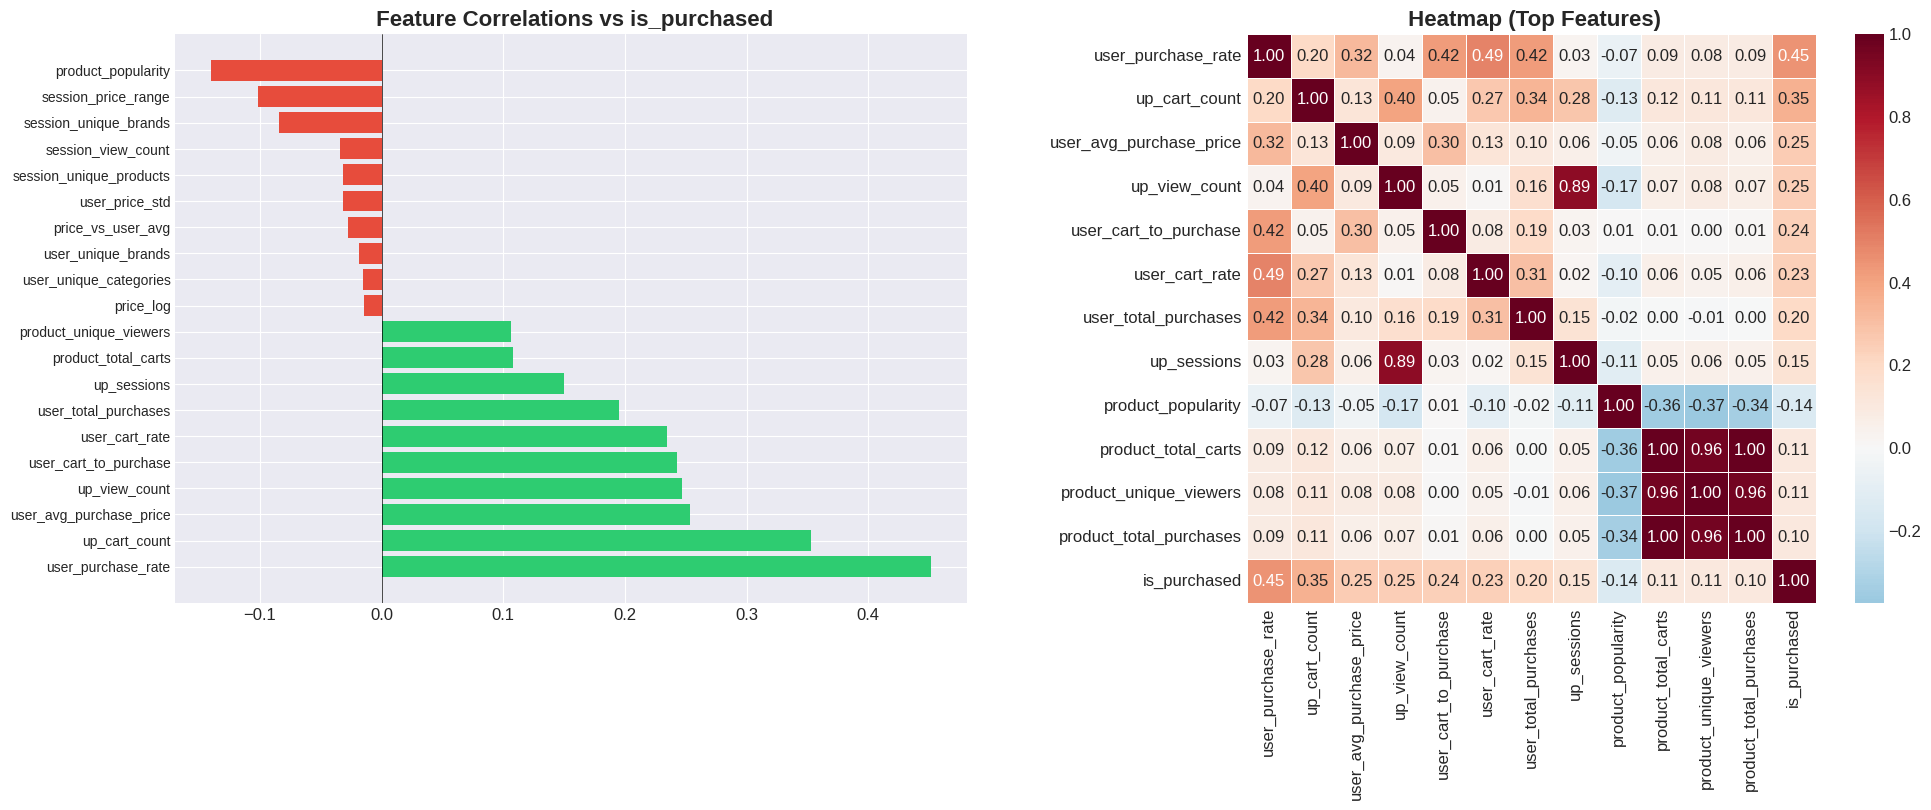

In [17]:
corr = df_ml[NUM_COLS + [LABEL]].corr()
target_corr = corr[LABEL].drop(LABEL).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
top_corr = pd.concat([target_corr.head(10), target_corr.tail(10)])
colors = ['#2ecc71' if v>0 else '#e74c3c' for v in top_corr.values]
axes[0].barh(range(len(top_corr)), top_corr.values, color=colors)
axes[0].set_yticks(range(len(top_corr))); axes[0].set_yticklabels(top_corr.index, fontsize=10)
axes[0].set_title(' Feature Correlations vs is_purchased', fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)

top_f = target_corr.abs().sort_values(ascending=False).head(12).index.tolist() + [LABEL]
sns.heatmap(df_ml[top_f].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1], square=True, linewidths=0.5)
axes[1].set_title(' Heatmap (Top Features)', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'correlation.png'), dpi=150, bbox_inches='tight'); plt.show()

## 8. Cân Bằng Lớp & Split

Trước — Class 1: 150,000 | Class 0: 1,850,000


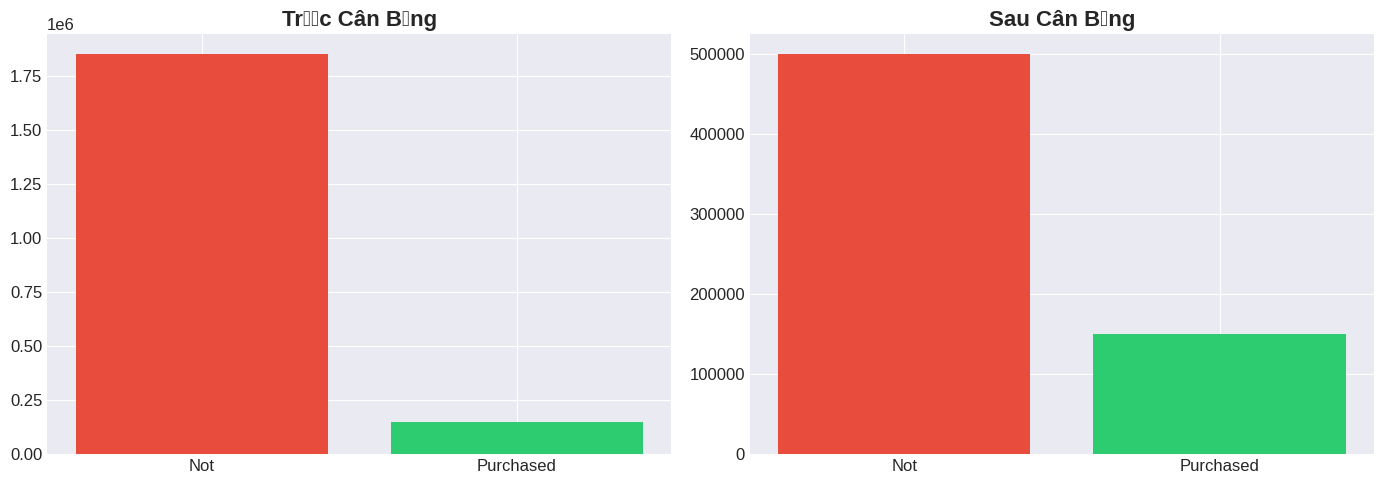


Train: 520,000 | Test: 130,000


In [20]:
# Sắp xếp theo thời gian trước khi split
df_ml = df_ml.sort_values('event_date').reset_index(drop=True)

# Split theo thời gian
cutoff = df_ml['event_date'].quantile(0.8)
train_df = df_ml[df_ml['event_date'] < cutoff].copy()
test_df = df_ml[df_ml['event_date'] >= cutoff].copy()

print(f"Train raw: {len(train_df):,} | Test raw: {len(test_df):,}")

# Balance CHỈ trên train
pos = train_df[train_df[LABEL] == 1]
neg = train_df[train_df[LABEL] == 0]

print(f"Trước balance train — Class 1: {len(pos):,} | Class 0: {len(neg):,}")

ratio = 3  # giữ khoảng 1:3 là ổn
n_pos = len(pos)
n_neg = min(len(neg), n_pos * ratio)

pos_s = pos.sample(n=n_pos, replace=False, random_state=42)
neg_s = neg.sample(n=n_neg, replace=False, random_state=42)

train_bal = pd.concat([pos_s, neg_s], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Not', 'Purchased'], [len(neg), len(pos)], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Trước Cân Bằng', fontweight='bold')

axes[1].bar(['Not', 'Purchased'], [(train_bal[LABEL] == 0).sum(), (train_bal[LABEL] == 1).sum()], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Sau Cân Bằng', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'balance.png'), dpi=150, bbox_inches='tight')
plt.show()

X_train = train_bal[ALL_FEATS]
y_train = train_bal[LABEL]

X_test = test_df[ALL_FEATS]
y_test = test_df[LABEL]

print(f'\nTrain: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

## 9. LightGBM Training

In [21]:
cat_idx = list(range(len(CAT_IDX)))

lgb_train = lgb.Dataset(
    X_train,
    label=y_train,
    categorical_feature=cat_idx,
    free_raw_data=False
)

lgb_valid = lgb.Dataset(
    X_test,
    label=y_test,
    reference=lgb_train,
    categorical_feature=cat_idx,
    free_raw_data=False
)

params = {
    'objective': 'binary',
    'metric': ['binary_logloss', 'auc'],
    'learning_rate': 0.03,
    'num_leaves': 255,
    'max_depth': -1,
    'min_child_samples': 30,
    'subsample': 0.8,
    'subsample_freq': 1,
    'colsample_bytree': 0.7,
    'reg_alpha': 0.3,
    'reg_lambda': 0.3,
    'min_gain_to_split': 0.0,
    'max_bin': 255,
    'is_unbalance': False,
    'n_jobs': -1,
    'verbose': -1,
    'seed': 42
}

evals_result = {}
callbacks = [
    lgb.early_stopping(100),
    lgb.log_evaluation(100),
    lgb.record_evaluation(evals_result)
]

t_train = time.time()
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_train, lgb_valid],
    valid_names=['train', 'valid'],
    callbacks=callbacks
)
print(f'\n Training: {time.time() - t_train:.2f}s | Best iter: {model.best_iteration}')

Training until validation scores don't improve for 100 rounds
[100]	train's binary_logloss: 0.100736	train's auc: 0.994356	valid's binary_logloss: 0.110698	valid's auc: 0.992183
[200]	train's binary_logloss: 0.0642407	train's auc: 0.997472	valid's binary_logloss: 0.0808922	valid's auc: 0.994829
[300]	train's binary_logloss: 0.0482986	train's auc: 0.998875	valid's binary_logloss: 0.0690841	valid's auc: 0.996182
[400]	train's binary_logloss: 0.0381107	train's auc: 0.9995	valid's binary_logloss: 0.0622644	valid's auc: 0.996847
[500]	train's binary_logloss: 0.0308604	train's auc: 0.999786	valid's binary_logloss: 0.0576642	valid's auc: 0.99723
[600]	train's binary_logloss: 0.0253702	train's auc: 0.999912	valid's binary_logloss: 0.0543228	valid's auc: 0.997471
[700]	train's binary_logloss: 0.0210319	train's auc: 0.999968	valid's binary_logloss: 0.0517953	valid's auc: 0.997635
[800]	train's binary_logloss: 0.0175699	train's auc: 0.99999	valid's binary_logloss: 0.0496904	valid's auc: 0.997773


## 10.  Đánh Giá

In [22]:
y_prob = model.predict(X_test, num_iteration=model.best_iteration)
y_pred = (y_prob >= 0.5).astype(int)

acc = metrics.accuracy_score(y_test, y_pred)
prec = metrics.precision_score(y_test, y_pred)
rec = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)
auc = metrics.roc_auc_score(y_test, y_prob)

print('='*50)
print('  📈  LIGHTGBM v2 — KẾT QUẢ')
print('='*50)
for name, val in [('Accuracy',acc),('Precision',prec),('Recall',rec),('F1',f1),('AUC',auc)]:
    print(f'  {name:12s}: {val:.4f}')
print('='*50)
print(metrics.classification_report(y_test, y_pred, target_names=['Not Purchased','Purchased']))

  📈  LIGHTGBM v2 — KẾT QUẢ
  Accuracy    : 0.9852
  Precision   : 0.9576
  Recall      : 0.9790
  F1          : 0.9682
  AUC         : 0.9982
               precision    recall  f1-score   support

Not Purchased       0.99      0.99      0.99    100000
    Purchased       0.96      0.98      0.97     30000

     accuracy                           0.99    130000
    macro avg       0.98      0.98      0.98    130000
 weighted avg       0.99      0.99      0.99    130000



## 11. Lưu Model

In [ ]:
model.save_model(MODEL_PATH)
print(f' Saved: {MODEL_PATH}')

## 12.  Loss & AUC Curves

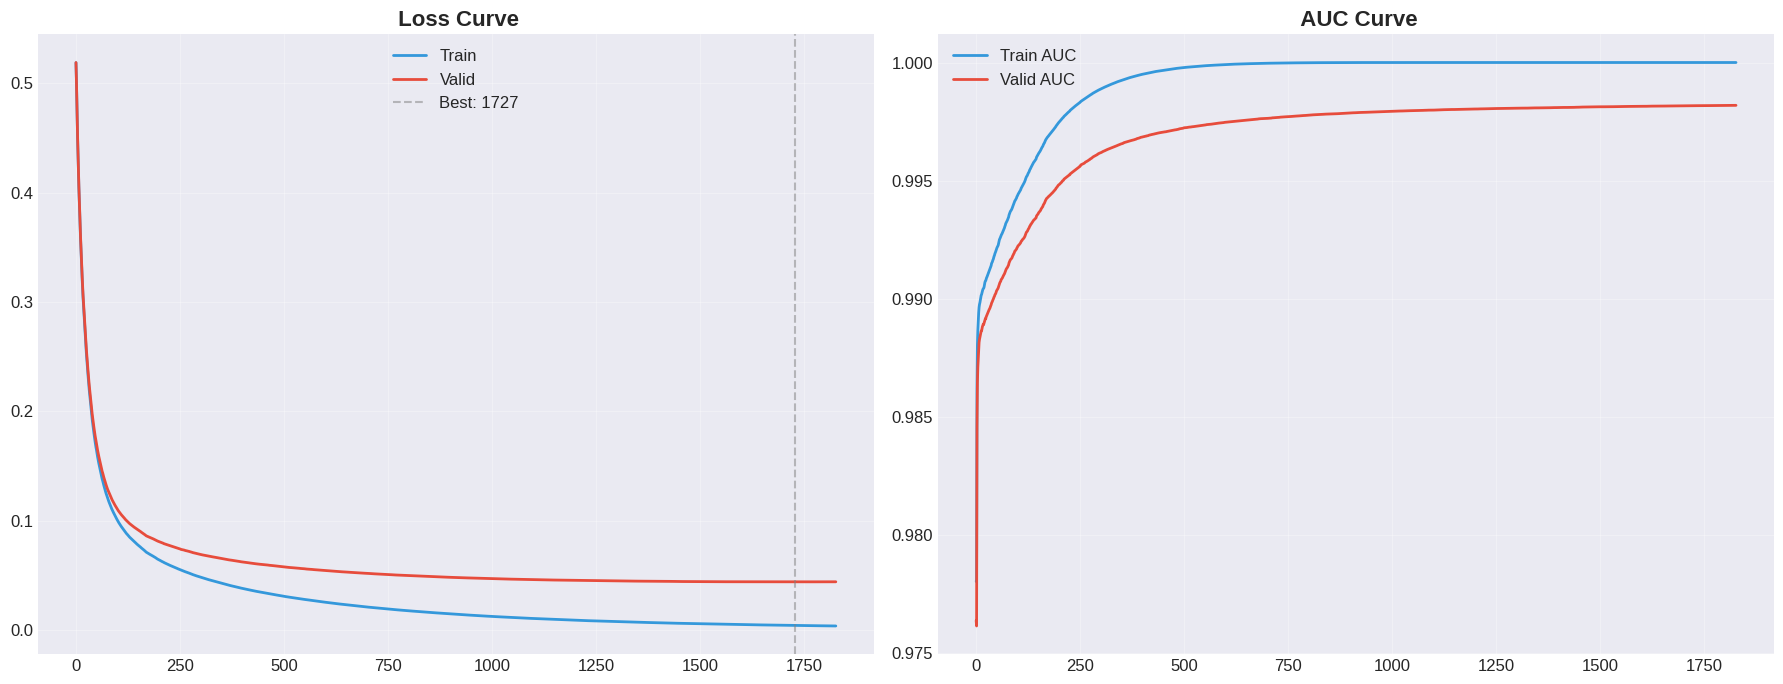

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
axes[0].plot(evals_result['train']['binary_logloss'], label='Train', color='#3498db', linewidth=2)
axes[0].plot(evals_result['valid']['binary_logloss'], label='Valid', color='#e74c3c', linewidth=2)
axes[0].axvline(model.best_iteration, color='gray', linestyle='--', alpha=0.5, label=f'Best: {model.best_iteration}')
axes[0].set_title(' Loss Curve', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(evals_result['train']['auc'], label='Train AUC', color='#3498db', linewidth=2)
axes[1].plot(evals_result['valid']['auc'], label='Valid AUC', color='#e74c3c', linewidth=2)
axes[1].set_title(' AUC Curve', fontweight='bold'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight'); plt.show()

## 13.  Feature Importance

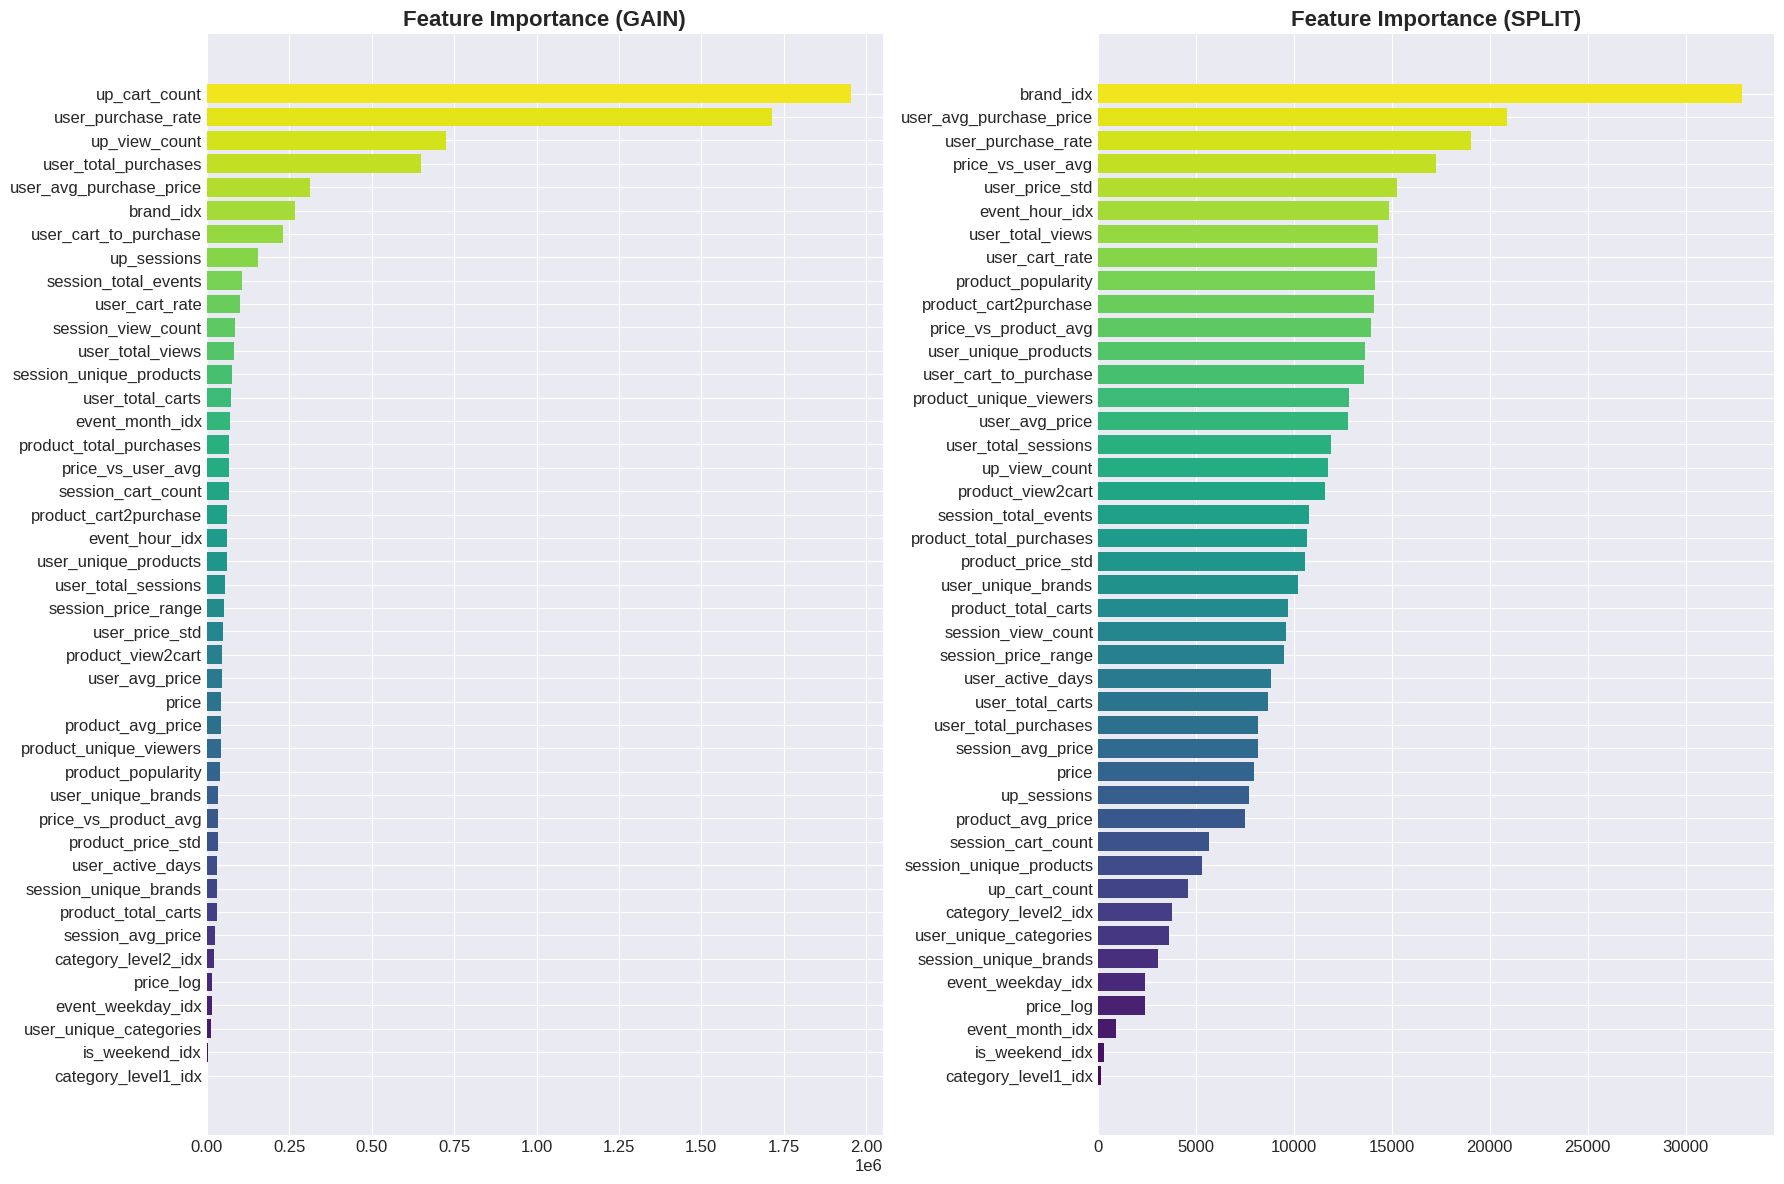


🏆 Top 15 Features:
                feature         gain  split
          up_cart_count 1.952910e+06   4564
     user_purchase_rate 1.715346e+06  19031
          up_view_count 7.251709e+05  11749
   user_total_purchases 6.480748e+05   8176
user_avg_purchase_price 3.114156e+05  20862
              brand_idx 2.679137e+05  32875
  user_cart_to_purchase 2.304588e+05  13553
            up_sessions 1.557910e+05   7681
   session_total_events 1.049518e+05  10762
         user_cart_rate 1.003161e+05  14217
     session_view_count 8.520464e+04   9573
       user_total_views 8.091490e+04  14288
session_unique_products 7.460490e+04   5318
       user_total_carts 7.246513e+04   8694
        event_month_idx 6.910339e+04    892


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
for i, imp in enumerate(['gain','split']):
    fi = pd.DataFrame({'feature': ALL_FEATS, 'imp': model.feature_importance(importance_type=imp)}).sort_values('imp', ascending=True)
    axes[i].barh(fi['feature'], fi['imp'], color=sns.color_palette('viridis', len(fi)))
    axes[i].set_title(f'Feature Importance ({imp.upper()})', fontweight='bold')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance_v2.png'), dpi=150, bbox_inches='tight'); plt.show()

fi_all = pd.DataFrame({'feature': ALL_FEATS, 'gain': model.feature_importance(importance_type='gain'),
    'split': model.feature_importance(importance_type='split')}).sort_values('gain', ascending=False)
print('\n🏆 Top 15 Features:'); print(fi_all.head(15).to_string(index=False))

## 14. ROC Curve & Confusion Matrix

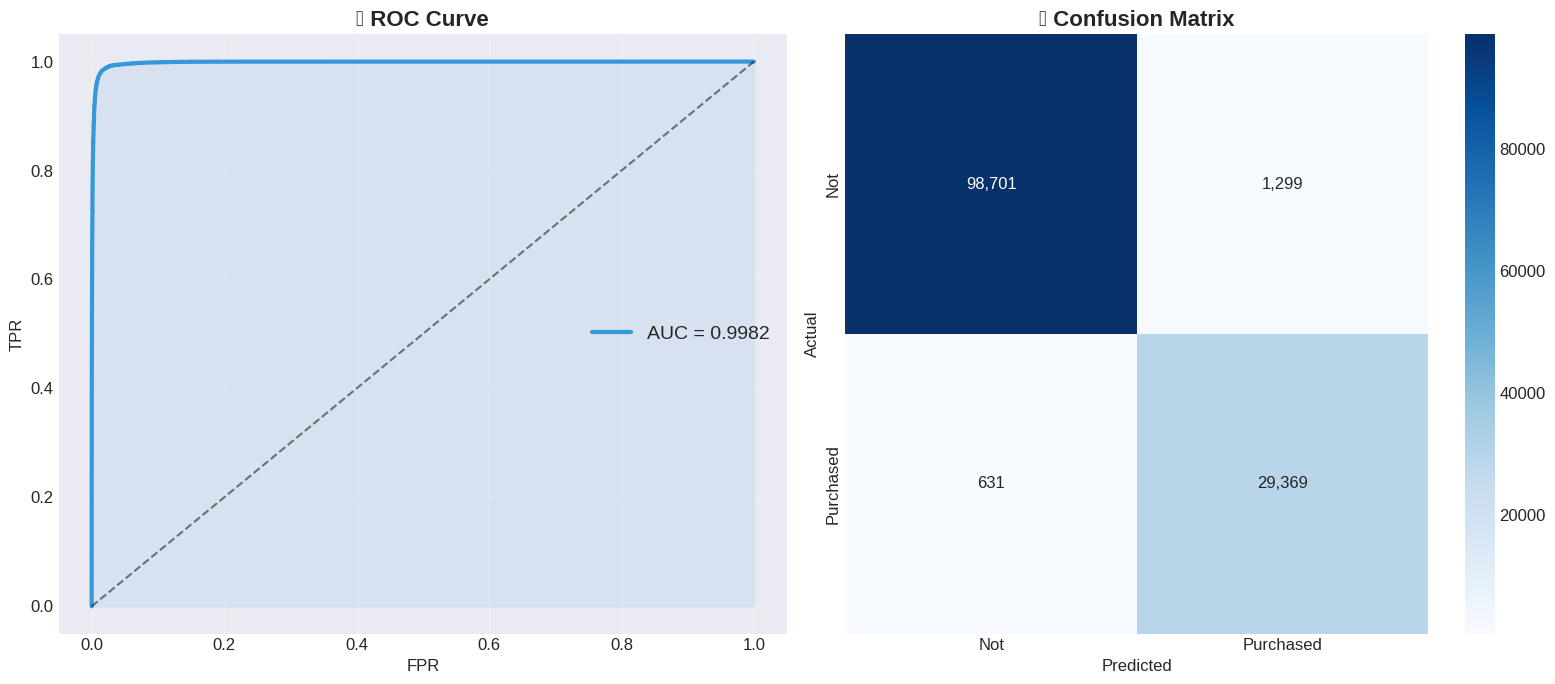

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
axes[0].plot(fpr, tpr, color='#3498db', linewidth=3, label=f'AUC = {auc:.4f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.5); axes[0].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[0].set_title('📈 ROC Curve', fontweight='bold'); axes[0].legend(fontsize=14); axes[0].grid(True, alpha=0.3)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')

cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=axes[1], xticklabels=['Not','Purchased'], yticklabels=['Not','Purchased'])
axes[1].set_title('🔲 Confusion Matrix', fontweight='bold'); axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'roc_confusion.png'), dpi=150, bbox_inches='tight'); plt.show()

## 15. Probability Distribution & Precision-Recall

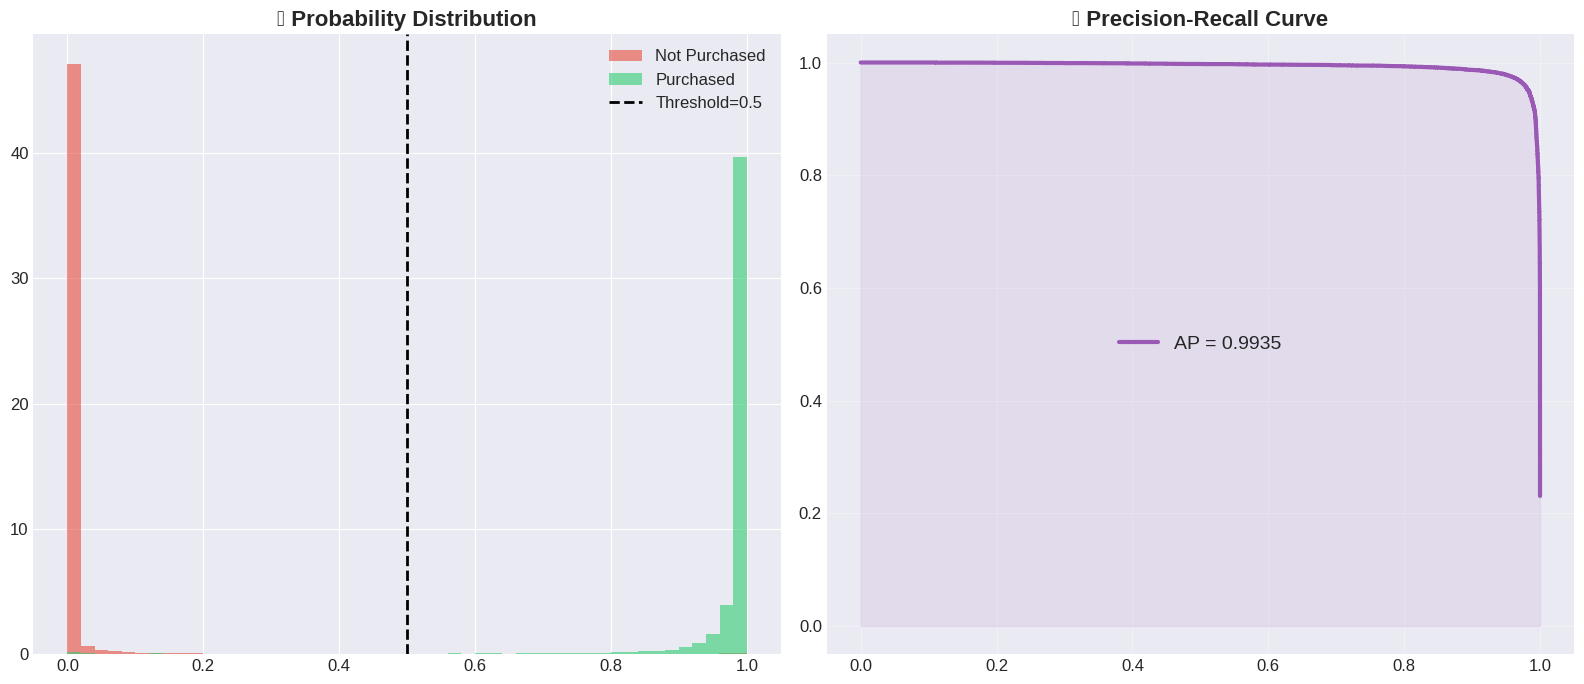

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].hist(y_prob[y_test==0], bins=50, alpha=0.6, color='#e74c3c', label='Not Purchased', density=True)
axes[0].hist(y_prob[y_test==1], bins=50, alpha=0.6, color='#2ecc71', label='Purchased', density=True)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold=0.5')
axes[0].set_title('📊 Probability Distribution', fontweight='bold'); axes[0].legend()

pr, re, _ = metrics.precision_recall_curve(y_test, y_prob)
ap = metrics.average_precision_score(y_test, y_prob)
axes[1].plot(re, pr, color='#9b59b6', linewidth=3, label=f'AP = {ap:.4f}')
axes[1].fill_between(re, pr, alpha=0.1, color='#9b59b6')
axes[1].set_title('📈 Precision-Recall Curve', fontweight='bold'); axes[1].legend(fontsize=14); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR, 'prob_pr.png'), dpi=150, bbox_inches='tight'); plt.show()

## 16.  Tổng Kết

In [27]:
print('='*60)
print('    TỔNG KẾT PIPELINE ')
print('='*60)
print(f'   Files        : {len(csv_files)} CSV')
print(f'   Raw rows     : {raw_count:,}')
print(f'   Clean rows   : {clean_count:,}')
print(f'   Features     : {len(ALL_FEATS)} ({len(CAT_IDX)} cat + {len(NUM_COLS)} num)')
print(f'   Accuracy     : {acc:.4f}')
print(f'   ROC-AUC      : {auc:.4f}')
print(f'   F1-Score     : {f1:.4f}')
print(f'   Model        : {MODEL_PATH}')
print('='*60)

    TỔNG KẾT PIPELINE 


NameError: name 'csv_files' is not defined

## 17. Dừng Spark

In [ ]:
spark.stop()
print(f'🎉 XONG! Kết quả: {OUTPUT_DIR}')